# Prompt Injection Experiment

Treino e avaliacao reproduziveis do detector que usa somente o `user_prompt`. O dataset combina SPML e `deepset/prompt-injections`.

In [1]:
from pathlib import Path
import json
import re
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

SEED = 42
EMBEDDING_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
TARGET_RECALL = 0.995
LATENCY_REPEATS = 5

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (cwd, *cwd.parents) if (path / "data").exists())
RESULTS_DIR = PROJECT_ROOT / "experiments" / "prompt_injection" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = PROJECT_ROOT / "data" / "prompt_injection.parquet"

PATTERN_DEFINITIONS = (
    ("has_exfiltration_verb", r"\b(?:reveal|show|display|print|repeat|expose|leak|output|provide|tell)\b"),
    ("has_instruction_term", r"\b(?:instruction|directive|rule|policy|guideline|constraint|restriction)s?\b"),
    ("has_you_are", r"\byou\s+are\b"),
    ("has_constraint_language", r"\b(?:must|never|do\s+not|must\s+not|should\s+not|refrain\s+from|under\s+no\s+circumstances)\b"),
    ("has_hash_delimiter", r"#{3,}"),
    ("has_override_verb", r"\b(?:ignore|disregard|forget|override|bypass|discard|supersede)\b"),
    ("has_ignore", r"\bignore\b"),
    ("has_override_instruction", r"\b(?:ignore|disregard|forget|override|bypass|discard|supersede)\b.{0,100}\b(?:instruction|directive|rule|policy|guideline|constraint|restriction|prompt)s?\b"),
    ("has_role_switch", r"\b(?:act\s+as|pretend|simulate|roleplay|you\s+are\s+now|new\s+role|from\s+now\s+on)\b"),
)
COMPILED_PATTERNS = tuple(re.compile(pattern, re.IGNORECASE | re.DOTALL) for _, pattern in PATTERN_DEFINITIONS)


def encode_prompts(model, prompts, batch_size=64, show_progress_bar=False):
    unique_prompts = list(dict.fromkeys(prompts))
    unique_embeddings = model.encode(
        unique_prompts,
        batch_size=batch_size,
        show_progress_bar=show_progress_bar,
        convert_to_numpy=True,
    ).astype(np.float32)
    embedding_by_prompt = dict(zip(unique_prompts, unique_embeddings, strict=True))
    return np.vstack([embedding_by_prompt[prompt] for prompt in prompts])


def preprocess_user_prompts(user_prompts, model, batch_size=64, show_progress_bar=False):
    embeddings = encode_prompts(model, user_prompts, batch_size, show_progress_bar)
    pattern_features = np.asarray(
        [[float(bool(pattern.search(prompt))) for pattern in COMPILED_PATTERNS] for prompt in user_prompts],
        dtype=np.float32,
    )
    features = np.hstack([embeddings, pattern_features]).astype(np.float32)
    assert features.shape[1] == 393
    return features


def add_cross_fitted_lda_feature(X_train, y_train, train_groups, *external_features):
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    train_score = np.empty((len(X_train), 1), dtype=np.float32)
    for fit_idx, score_idx in splitter.split(X_train, y_train, groups=train_groups):
        fold_lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
        fold_lda.fit(X_train[fit_idx], y_train[fit_idx])
        train_score[score_idx, 0] = fold_lda.decision_function(X_train[score_idx])

    final_lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    final_lda.fit(X_train, y_train)
    augmented_train = np.hstack([X_train, train_score]).astype(np.float32)
    augmented_external = tuple(
        np.hstack([features, final_lda.decision_function(features).reshape(-1, 1)]).astype(np.float32)
        for features in external_features
    )
    return (augmented_train, *augmented_external), final_lda


def metrics_at_threshold(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "false_positive_rate": fp / (fp + tn) if fp + tn else 0.0,
        "false_negative_rate": fn / (fn + tp) if fn + tp else 0.0,
        "false_positives": int(fp),
        "false_negatives": int(fn),
    }


def select_threshold(y_true, probabilities, target_recall):
    table = pd.DataFrame(
        metrics_at_threshold(y_true, probabilities, threshold)
        for threshold in np.linspace(0.001, 0.999, 999)
    )
    eligible = table[table["recall"].ge(target_recall)]
    selected = (
        eligible.sort_values(["false_positive_rate", "threshold"], ascending=[True, False]).iloc[0]
        if not eligible.empty
        else table.sort_values(["recall", "false_positive_rate"], ascending=[False, True]).iloc[0]
    )
    return float(selected["threshold"]), table


def measure_prediction_latency(model, features, repeats=LATENCY_REPEATS):
    model.predict_proba(features[: min(32, len(features))])
    durations = []
    for _ in range(repeats):
        started_at = perf_counter()
        model.predict_proba(features)
        durations.append(perf_counter() - started_at)
    return float(np.median(durations) * 1000 / len(features))

RESULTS_DIR

/home/patrickoliveira/aws-bedrock-practice/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/home/patrickoliveira/aws-bedrock-practice/extra_practice_10/ml_guardrail/experiments/prompt_injection/results')

## Dataset

Auditoria de schema, fontes, classes e splits antes do treinamento.

In [2]:
data = pd.read_parquet(DATA_PATH)
expected_columns = {"user_prompt", "prompt_injection", "split", "source", "sample_id"}
assert expected_columns.issubset(data.columns)
assert set(data["prompt_injection"].unique()) == {0, 1}

split_prompts = {
    split: set(frame["user_prompt"])
    for split, frame in data.groupby("split")
}
assert split_prompts["train"].isdisjoint(split_prompts["validation"])
assert split_prompts["train"].isdisjoint(split_prompts["test"])
assert split_prompts["validation"].isdisjoint(split_prompts["test"])

dataset_summary = data.groupby(["split", "source", "prompt_injection"]).size().rename("rows").reset_index()
print(f"Rows: {len(data):,}")
display(dataset_summary)

Rows: 17,323


,split,source,prompt_injection,rows
0,test,Yash0728/toxicity_prompt-injection,0,26
1,test,Yash0728/toxicity_prompt-injection,1,82
2,test,deepset/prompt-injections,0,65
3,test,deepset/prompt-injections,1,47
4,test,reshabhs/SPML_Chatbot_Prompt_Injection,0,488
5,test,reshabhs/SPML_Chatbot_Prompt_Injection,1,1891
6,train,Yash0728/toxicity_prompt-injection,0,138
7,train,Yash0728/toxicity_prompt-injection,1,389
8,train,deepset/prompt-injections,0,269
9,train,deepset/prompt-injections,1,176


## Hyperparameter tuning, training and probability calibration

Decision Tree, Random Forest e XGBoost usam uma grade compacta com tres configuracoes dos hiperparametros de maior impacto. A selecao usa somente a validacao, sem consultar o teste.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   4%|▎         | 7/199 [00:00<00:03, 61.82it/s]

Loading weights:  11%|█         | 21/199 [00:00<00:01, 96.25it/s]

Loading weights:  16%|█▌        | 32/199 [00:00<00:01, 98.83it/s]

Loading weights:  24%|██▎       | 47/199 [00:00<00:01, 115.45it/s]

...

Batches:  93%|█████████▎| 38/41 [01:12<00:01,  1.93it/s]

Batches:  95%|█████████▌| 39/41 [01:13<00:00,  2.05it/s]

Batches:  98%|█████████▊| 40/41 [01:13<00:00,  2.30it/s]

Batches: 100%|██████████| 41/41 [01:13<00:00,  2.85it/s]

Batches: 100%|██████████| 41/41 [01:13<00:00,  1.80s/it]

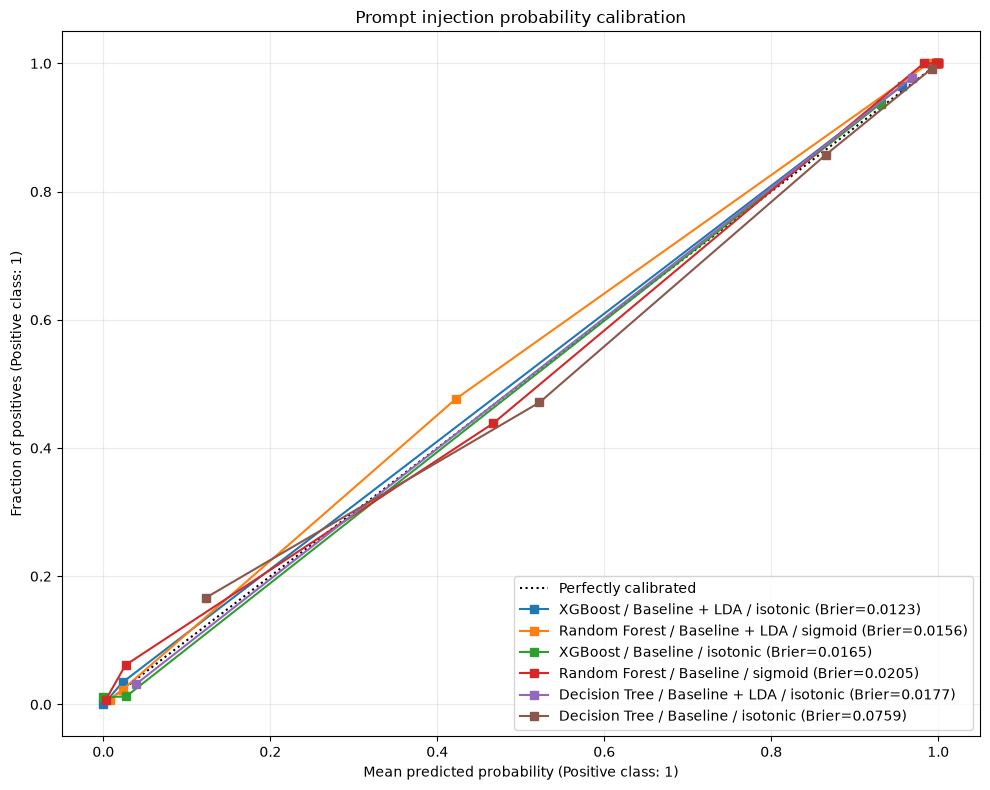

Best candidate by validation PR-AUC: XGBoost / Baseline + LDA


,candidate,configuration,model,feature_set,hyperparameters,calibration_method,brier_score,validation_pr_auc,validation_roc_auc
0,Decision Tree / Baseline,1,Decision Tree,Baseline,"{""max_depth"": 8, ""min_samples_leaf"": 10}",isotonic,0.075921,0.975305,0.946733
1,Decision Tree / Baseline,2,Decision Tree,Baseline,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.081163,0.950392,0.909001
2,Decision Tree / Baseline,3,Decision Tree,Baseline,"{""max_depth"": null, ""min_samples_leaf"": 2}",isotonic,0.093188,0.923056,0.866227
10,Decision Tree / Baseline + LDA,2,Decision Tree,Baseline + LDA,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.017701,0.992103,0.986345
9,Decision Tree / Baseline + LDA,1,Decision Tree,Baseline + LDA,"{""max_depth"": 8, ""min_samples_leaf"": 10}",sigmoid,0.020930,0.991030,0.977746
11,Decision Tree / Baseline + LDA,3,Decision Tree,Baseline + LDA,"{""max_depth"": null, ""min_samples_leaf"": 2}",isotonic,0.022283,0.985147,0.975549
4,Random Forest / Baseline,2,Random Forest,Baseline,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",sigmoid,0.020497,0.998385,0.994568
5,Random Forest / Baseline,3,Random Forest,Baseline,"{""max_depth"": null, ""min_samples_leaf"": 2, ""n_...",sigmoid,0.021089,0.998328,0.994394
3,Random Forest / Baseline,1,Random Forest,Baseline,"{""max_depth"": 12, ""min_samples_leaf"": 5, ""n_es...",sigmoid,0.021616,0.998255,0.994198
13,Random Forest / Baseline + LDA,2,Random Forest,Baseline + LDA,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",sigmoid,0.015565,0.998955,0.996470


,candidate,configuration,model,feature_set,hyperparameters,method,brier_score
1,Decision Tree / Baseline,1,Decision Tree,Baseline,"{""max_depth"": 8, ""min_samples_leaf"": 10}",isotonic,0.075921
0,Decision Tree / Baseline,1,Decision Tree,Baseline,"{""max_depth"": 8, ""min_samples_leaf"": 10}",sigmoid,0.076114
3,Decision Tree / Baseline,2,Decision Tree,Baseline,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.081163
2,Decision Tree / Baseline,2,Decision Tree,Baseline,"{""max_depth"": 12, ""min_samples_leaf"": 5}",sigmoid,0.083324
5,Decision Tree / Baseline,3,Decision Tree,Baseline,"{""max_depth"": null, ""min_samples_leaf"": 2}",isotonic,0.093188
4,Decision Tree / Baseline,3,Decision Tree,Baseline,"{""max_depth"": null, ""min_samples_leaf"": 2}",sigmoid,0.093655
18,Decision Tree / Baseline + LDA,1,Decision Tree,Baseline + LDA,"{""max_depth"": 8, ""min_samples_leaf"": 10}",sigmoid,0.020930
19,Decision Tree / Baseline + LDA,1,Decision Tree,Baseline + LDA,"{""max_depth"": 8, ""min_samples_leaf"": 10}",isotonic,0.021385
21,Decision Tree / Baseline + LDA,2,Decision Tree,Baseline + LDA,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.017701
20,Decision Tree / Baseline + LDA,2,Decision Tree,Baseline + LDA,"{""max_depth"": 12, ""min_samples_leaf"": 5}",sigmoid,0.020167


,candidate,model,feature_set,hyperparameters,calibration_method,brier_score,validation_pr_auc,validation_roc_auc,threshold,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,false_positives,false_negatives
0,XGBoost / Baseline + LDA,XGBoost,Baseline + LDA,"{""learning_rate"": 0.1, ""max_depth"": 4, ""n_esti...",isotonic,0.012340,0.999316,0.998430,0.022,0.886836,0.868984,1.000000,0.929900,0.453704,0.000000,147,0
1,Random Forest / Baseline + LDA,Random Forest,Baseline + LDA,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",sigmoid,0.015565,0.998955,0.996470,0.041,0.946882,0.937259,0.995897,0.965689,0.200617,0.004103,65,4
2,XGBoost / Baseline,XGBoost,Baseline,"{""learning_rate"": 0.1, ""max_depth"": 4, ""n_esti...",isotonic,0.016459,0.998641,0.996583,0.063,0.949962,0.940039,0.996923,0.967646,0.191358,0.003077,62,3
3,Random Forest / Baseline,Random Forest,Baseline,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",sigmoid,0.020497,0.998385,0.994568,0.028,0.906851,0.892463,0.995897,0.941348,0.361111,0.004103,117,4
4,Decision Tree / Baseline + LDA,Decision Tree,Baseline + LDA,"{""max_depth"": 12, ""min_samples_leaf"": 5}",isotonic,0.017701,0.992103,0.986345,0.039,0.750577,0.750577,1.000000,0.857520,1.000000,0.000000,324,0
5,Decision Tree / Baseline,Decision Tree,Baseline,"{""max_depth"": 8, ""min_samples_leaf"": 10}",isotonic,0.075921,0.975305,0.946733,0.045,0.750577,0.750577,1.000000,0.857520,1.000000,0.000000,324,0


In [3]:
train_data = data[data["split"].eq("train")].reset_index(drop=True)
validation_data = data[data["split"].eq("validation")].reset_index(drop=True)
test_data = data[data["split"].eq("test")].reset_index(drop=True)

validation_splitter = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
calibration_idx, threshold_idx = next(
    validation_splitter.split(
        validation_data,
        y=validation_data["prompt_injection"],
        groups=validation_data["user_prompt"],
    )
)
calibration_data = validation_data.iloc[calibration_idx].reset_index(drop=True)
threshold_data = validation_data.iloc[threshold_idx].reset_index(drop=True)

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
X_train_base = preprocess_user_prompts(train_data["user_prompt"].tolist(), embedding_model, show_progress_bar=True)
X_calibration_base = preprocess_user_prompts(calibration_data["user_prompt"].tolist(), embedding_model, show_progress_bar=True)
X_threshold_base = preprocess_user_prompts(threshold_data["user_prompt"].tolist(), embedding_model, show_progress_bar=True)
test_preprocessing_started = perf_counter()
X_test_base = preprocess_user_prompts(test_data["user_prompt"].tolist(), embedding_model, show_progress_bar=True)
preprocessing_latency_ms_per_sample = (perf_counter() - test_preprocessing_started) * 1000 / len(test_data)

y_train = train_data["prompt_injection"].to_numpy()
y_calibration = calibration_data["prompt_injection"].to_numpy()
y_threshold = threshold_data["prompt_injection"].to_numpy()
y_test = test_data["prompt_injection"].to_numpy()
negative_count, positive_count = np.bincount(y_train)

lda_features, final_lda = add_cross_fitted_lda_feature(
    X_train_base,
    y_train,
    train_data["user_prompt"].to_numpy(),
    X_calibration_base,
    X_threshold_base,
    X_test_base,
)
feature_sets = {
    "Baseline": (X_train_base, X_calibration_base, X_threshold_base, X_test_base),
    "Baseline + LDA": lda_features,
}
assert feature_sets["Baseline + LDA"][0].shape[1] == 394

hyperparameter_grids = {
    "Decision Tree": [
        {"max_depth": 8, "min_samples_leaf": 10},
        {"max_depth": 12, "min_samples_leaf": 5},
        {"max_depth": None, "min_samples_leaf": 2},
    ],
    "Random Forest": [
        {"n_estimators": 200, "max_depth": 12, "min_samples_leaf": 5},
        {"n_estimators": 300, "max_depth": 18, "min_samples_leaf": 2},
        {"n_estimators": 400, "max_depth": None, "min_samples_leaf": 2},
    ],
    "XGBoost": [
        {"n_estimators": 200, "max_depth": 4, "learning_rate": 0.10},
        {"n_estimators": 300, "max_depth": 6, "learning_rate": 0.10},
        {"n_estimators": 400, "max_depth": 4, "learning_rate": 0.05},
    ],
}


def build_estimator(model_name, parameters):
    if model_name == "Decision Tree":
        return DecisionTreeClassifier(
            **parameters,
            class_weight="balanced",
            random_state=SEED,
        )
    if model_name == "Random Forest":
        return RandomForestClassifier(
            **parameters,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=SEED,
        )
    return XGBClassifier(
        **parameters,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=negative_count / positive_count,
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED,
    )


calibrated_models = {}
model_feature_sets = {}
selected_thresholds = {}
threshold_tables = {}
validation_probabilities = {}
calibration_rows = []
tuning_rows = []
model_selection_rows = []

for feature_set_name, (X_train, X_calibration, X_threshold, X_test) in feature_sets.items():
    for model_name, parameter_grid in hyperparameter_grids.items():
        candidate_name = f"{model_name} / {feature_set_name}"
        tuned_candidates = []
        for configuration_index, parameters in enumerate(parameter_grid, start=1):
            pipeline = Pipeline([
                ("preprocessing", "passthrough"),
                ("classifier", build_estimator(model_name, parameters)),
            ]).fit(X_train, y_train)

            calibration_candidates = {}
            for method in ("sigmoid", "isotonic"):
                calibrated_candidate = CalibratedClassifierCV(
                    FrozenEstimator(pipeline),
                    method=method,
                ).fit(X_calibration, y_calibration)
                candidate_probability = calibrated_candidate.predict_proba(X_threshold)[:, 1]
                brier = brier_score_loss(y_threshold, candidate_probability)
                calibration_candidates[method] = (
                    calibrated_candidate,
                    candidate_probability,
                    brier,
                )
                calibration_rows.append({
                    "candidate": candidate_name,
                    "configuration": configuration_index,
                    "model": model_name,
                    "feature_set": feature_set_name,
                    "hyperparameters": json.dumps(parameters, sort_keys=True),
                    "method": method,
                    "brier_score": brier,
                })

            best_method = min(
                calibration_candidates,
                key=lambda method: calibration_candidates[method][2],
            )
            calibrated_model, threshold_probability, best_brier = calibration_candidates[best_method]
            validation_pr_auc = average_precision_score(y_threshold, threshold_probability)
            validation_roc_auc = roc_auc_score(y_threshold, threshold_probability)
            tuning_rows.append({
                "candidate": candidate_name,
                "configuration": configuration_index,
                "model": model_name,
                "feature_set": feature_set_name,
                "hyperparameters": json.dumps(parameters, sort_keys=True),
                "calibration_method": best_method,
                "brier_score": best_brier,
                "validation_pr_auc": validation_pr_auc,
                "validation_roc_auc": validation_roc_auc,
            })
            tuned_candidates.append({
                "parameters": parameters,
                "calibration_method": best_method,
                "model": calibrated_model,
                "probabilities": threshold_probability,
                "brier_score": best_brier,
                "validation_pr_auc": validation_pr_auc,
                "validation_roc_auc": validation_roc_auc,
            })

        best_tuned_candidate = max(
            tuned_candidates,
            key=lambda item: (
                item["validation_pr_auc"],
                item["validation_roc_auc"],
                -item["brier_score"],
            ),
        )
        calibrated_model = best_tuned_candidate["model"]
        threshold_probability = best_tuned_candidate["probabilities"]
        selected_threshold, threshold_table = select_threshold(
            y_threshold,
            threshold_probability,
            TARGET_RECALL,
        )
        threshold_metrics = metrics_at_threshold(
            y_threshold,
            threshold_probability,
            selected_threshold,
        )
        calibrated_models[candidate_name] = calibrated_model
        model_feature_sets[candidate_name] = feature_set_name
        selected_thresholds[candidate_name] = selected_threshold
        threshold_tables[candidate_name] = threshold_table.assign(candidate=candidate_name)
        validation_probabilities[candidate_name] = threshold_probability
        model_selection_rows.append({
            "candidate": candidate_name,
            "model": model_name,
            "feature_set": feature_set_name,
            "hyperparameters": json.dumps(best_tuned_candidate["parameters"], sort_keys=True),
            "calibration_method": best_tuned_candidate["calibration_method"],
            "brier_score": best_tuned_candidate["brier_score"],
            "validation_pr_auc": best_tuned_candidate["validation_pr_auc"],
            "validation_roc_auc": best_tuned_candidate["validation_roc_auc"],
            **threshold_metrics,
        })

calibration_comparison = pd.DataFrame(calibration_rows).sort_values(
    ["candidate", "configuration", "brier_score"]
)
hyperparameter_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["candidate", "validation_pr_auc", "validation_roc_auc"],
    ascending=[True, False, False],
)
model_selection_comparison = pd.DataFrame(model_selection_rows).sort_values(
    ["validation_pr_auc", "validation_roc_auc"], ascending=False
).reset_index(drop=True)
best_model_name = model_selection_comparison.iloc[0]["candidate"]

fig, axis = plt.subplots(figsize=(10, 8))
for row in model_selection_comparison.itertuples():
    CalibrationDisplay.from_predictions(
        y_threshold,
        validation_probabilities[row.candidate],
        n_bins=10,
        strategy="quantile",
        name=f"{row.candidate} / {row.calibration_method} (Brier={row.brier_score:.4f})",
        ax=axis,
    )
axis.set_title("Prompt injection probability calibration")
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "calibration_plot.png", dpi=160)
plt.show()

print(f"Best candidate by validation PR-AUC: {best_model_name}")
display(hyperparameter_tuning)
display(calibration_comparison)
display(model_selection_comparison)

## Test evaluation, latency and exports

Avaliacao final no teste com threshold selecionado na validacao. A latencia de preprocessing e medida em lote uma vez; a latencia de `predict_proba` usa aquecimento e a mediana de cinco repeticoes. Ambas sao reportadas em milissegundos por amostra.

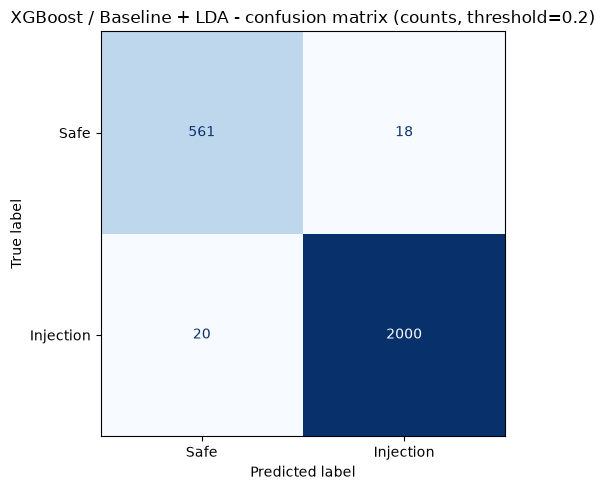

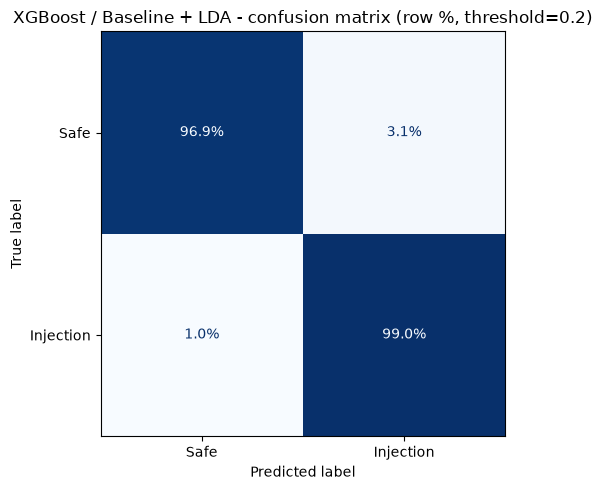

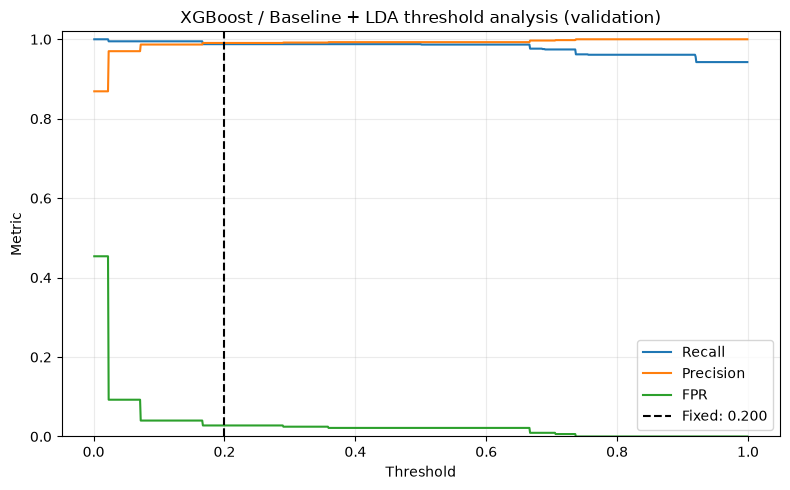

Selected candidate: XGBoost / Baseline + LDA
Fixed evaluation threshold: 0.200


,candidate,model,feature_set,hyperparameters,selected_on_validation,calibration_method,threshold,accuracy,precision,recall,f1,false_positive_rate,false_negative_rate,false_positives,false_negatives,roc_auc,pr_auc,preprocessing_latency_ms_per_sample,model_latency_ms_per_sample,end_to_end_latency_ms_per_sample
0,XGBoost / Baseline + LDA,XGBoost,Baseline + LDA,"{""learning_rate"": 0.1, ""max_depth"": 4, ""n_esti...",True,isotonic,0.2,0.985379,0.991080,0.990099,0.990589,0.031088,0.009901,18,20,0.998472,0.999499,28.536785,0.002655,28.539440
1,Random Forest / Baseline + LDA,Random Forest,Baseline + LDA,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",False,sigmoid,0.2,0.982301,0.989583,0.987624,0.988603,0.036269,0.012376,21,25,0.997705,0.999389,28.536785,0.064992,28.601778
2,Random Forest / Baseline,Random Forest,Baseline,"{""max_depth"": 18, ""min_samples_leaf"": 2, ""n_es...",False,sigmoid,0.2,0.964217,0.963444,0.991584,0.977312,0.131261,0.008416,76,17,0.995625,0.998812,28.536785,0.069795,28.606580
3,XGBoost / Baseline,XGBoost,Baseline,"{""learning_rate"": 0.1, ""max_depth"": 4, ""n_esti...",False,isotonic,0.2,0.973836,0.975170,0.991584,0.983309,0.088083,0.008416,51,17,0.993780,0.997296,28.536785,0.004083,28.540868
4,Decision Tree / Baseline + LDA,Decision Tree,Baseline + LDA,"{""max_depth"": 12, ""min_samples_leaf"": 5}",False,isotonic,0.2,0.979608,0.983768,0.990099,0.986923,0.056995,0.009901,33,20,0.984964,0.992189,28.536785,0.000681,28.537466
5,Decision Tree / Baseline,Decision Tree,Baseline,"{""max_depth"": 8, ""min_samples_leaf"": 10}",False,isotonic,0.2,0.892651,0.903196,0.965347,0.933238,0.360967,0.034653,209,70,0.944232,0.975295,28.536785,0.000890,28.537675


,predicted_safe,predicted_injection
actual_safe,561,18
actual_injection,20,2000


,predicted_safe,predicted_injection
actual_safe,96.9%,3.1%
actual_injection,1.0%,99.0%


In [4]:
EVALUATION_THRESHOLD = 0.2

test_probabilities_by_model = {
    candidate_name: model.predict_proba(
        feature_sets[model_feature_sets[candidate_name]][3]
    )[:, 1]
    for candidate_name, model in calibrated_models.items()
}

test_rows = []
for candidate_name, probabilities in test_probabilities_by_model.items():
    test_features = feature_sets[model_feature_sets[candidate_name]][3]
    model_latency_ms_per_sample = measure_prediction_latency(
        calibrated_models[candidate_name],
        test_features,
    )
    model_metrics = metrics_at_threshold(
        y_test,
        probabilities,
        EVALUATION_THRESHOLD,
    )
    selection_row = model_selection_comparison[
        model_selection_comparison["candidate"].eq(candidate_name)
    ].iloc[0]
    test_rows.append({
        "candidate": candidate_name,
        "model": selection_row["model"],
        "feature_set": selection_row["feature_set"],
        "hyperparameters": selection_row["hyperparameters"],
        "selected_on_validation": candidate_name == best_model_name,
        "calibration_method": selection_row["calibration_method"],
        **model_metrics,
        "roc_auc": roc_auc_score(y_test, probabilities),
        "pr_auc": average_precision_score(y_test, probabilities),
        "preprocessing_latency_ms_per_sample": preprocessing_latency_ms_per_sample,
        "model_latency_ms_per_sample": model_latency_ms_per_sample,
        "end_to_end_latency_ms_per_sample": (
            preprocessing_latency_ms_per_sample + model_latency_ms_per_sample
        ),
    })

model_comparison = pd.DataFrame(test_rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)

test_probabilities = test_probabilities_by_model[best_model_name]
selected_threshold = EVALUATION_THRESHOLD
threshold_table = threshold_tables[best_model_name].drop(columns="candidate")
predictions = (test_probabilities >= selected_threshold).astype(int)
count_matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
percentage_matrix = confusion_matrix(y_test, predictions, labels=[0, 1], normalize="true")
labels = ["Safe", "Injection"]

fig, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(count_matrix, display_labels=labels).plot(
    ax=axis, cmap="Blues", colorbar=False, values_format="d"
)
axis.set_title(f"{best_model_name} - confusion matrix (counts, threshold=0.2)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix_counts.png", dpi=160)
plt.show()

fig, axis = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(percentage_matrix, display_labels=labels).plot(
    ax=axis, cmap="Blues", colorbar=False, values_format=".1%"
)
axis.set_title(f"{best_model_name} - confusion matrix (row %, threshold=0.2)")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "confusion_matrix_percentages.png", dpi=160)
plt.show()

fig, axis = plt.subplots(figsize=(8, 5))
axis.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
axis.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
axis.plot(threshold_table["threshold"], threshold_table["false_positive_rate"], label="FPR")
axis.axvline(selected_threshold, color="black", linestyle="--", label=f"Fixed: {selected_threshold:.3f}")
axis.set(xlabel="Threshold", ylabel="Metric", ylim=(0, 1.02), title=f"{best_model_name} threshold analysis (validation)")
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "threshold_analysis.png", dpi=160)
plt.show()

confusion_counts = pd.DataFrame(count_matrix, index=["actual_safe", "actual_injection"], columns=["predicted_safe", "predicted_injection"])
confusion_percentages = pd.DataFrame(percentage_matrix, index=["actual_safe", "actual_injection"], columns=["predicted_safe", "predicted_injection"])
all_threshold_tables = pd.concat(threshold_tables.values(), ignore_index=True)
with pd.ExcelWriter(RESULTS_DIR / "results.xlsx", engine="openpyxl") as writer:
    dataset_summary.to_excel(writer, sheet_name="dataset_distribution", index=False)
    hyperparameter_tuning.to_excel(writer, sheet_name="hyperparameter_tuning", index=False)
    calibration_comparison.to_excel(writer, sheet_name="calibration", index=False)
    model_selection_comparison.to_excel(writer, sheet_name="validation_comparison", index=False)
    model_comparison.to_excel(writer, sheet_name="test_comparison", index=False)
    all_threshold_tables.to_excel(writer, sheet_name="threshold_analysis", index=False)
    confusion_counts.to_excel(writer, sheet_name="confusion_counts")
    confusion_percentages.to_excel(writer, sheet_name="confusion_percentages")

print(f"Selected candidate: {best_model_name}")
print(f"Fixed evaluation threshold: {selected_threshold:.3f}")
display(model_comparison)
display(confusion_counts)
display(confusion_percentages.style.format("{:.1%}"))

In [5]:
expected_results = {
    RESULTS_DIR / "calibration_plot.png",
    RESULTS_DIR / "confusion_matrix_counts.png",
    RESULTS_DIR / "confusion_matrix_percentages.png",
    RESULTS_DIR / "threshold_analysis.png",
    RESULTS_DIR / "results.xlsx",
}
missing_results = [path for path in expected_results if not path.exists()]
assert not missing_results, f"Missing results: {missing_results}"
assert model_comparison[[
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"
]].apply(lambda column: column.between(0.0, 1.0).all()).all()
assert model_comparison[[
    "preprocessing_latency_ms_per_sample",
    "model_latency_ms_per_sample",
    "end_to_end_latency_ms_per_sample",
]].gt(0.0).all().all()
assert len(hyperparameter_tuning) == len(feature_sets) * sum(
    len(configurations) for configurations in hyperparameter_grids.values()
)
print("Experiment completed successfully")
print("\n".join(str(path.relative_to(PROJECT_ROOT)) for path in sorted(expected_results)))

Experiment completed successfully
experiments/prompt_injection/results/calibration_plot.png
experiments/prompt_injection/results/confusion_matrix_counts.png
experiments/prompt_injection/results/confusion_matrix_percentages.png
experiments/prompt_injection/results/results.xlsx
experiments/prompt_injection/results/threshold_analysis.png


In [6]:
# ---- ADDED for extra practice 10 (not in the original notebook): save the validation winner ----
import joblib
ARTIFACT_DIR = PROJECT_ROOT.parent / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
_feature_set = model_feature_sets[best_model_name]
joblib.dump({
    "name": "prompt_injection",
    "candidate": best_model_name,
    "model": calibrated_models[best_model_name],
    "lda": final_lda if _feature_set == "Baseline + LDA" else None,
    "threshold": EVALUATION_THRESHOLD,
    "embedding_model": EMBEDDING_MODEL_NAME,
}, ARTIFACT_DIR / "prompt_injection.joblib")
print("saved", ARTIFACT_DIR / "prompt_injection.joblib", "| candidate:", best_model_name, "| threshold:", EVALUATION_THRESHOLD)

saved /home/patrickoliveira/aws-bedrock-practice/extra_practice_10/artifacts/prompt_injection.joblib | candidate: XGBoost / Baseline + LDA | threshold: 0.2
